# Pygformula pipeline with features identiying L

In [1]:
import numpy as np
import pygformula
from pygformula import ParametricGformula
from pygformula.interventions import static

In [2]:
import pandas as pd

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
%matplotlib ipympl

In [5]:
import lightgbm as lgb
import re

# Load MIMIC data

In [6]:
mimicdata = pd.read_parquet('../Dataset/mimic-iv/from_pipeline/ltm_grided_clipped_A_D_Z_Y_SelfPipeline.parquet')

In [7]:
mimicdata.shape

(599174, 41)

In [8]:
mimicdata.columns

Index(['stay_id', 'grid_end', 'vent_mode__hours_since_last__last_12h',
       'temperature__mean__last_12h', 'heart_rate__mean__last_12h',
       'arterial_blood_pressure_mean__mean__last_12h',
       'fluid_out_urine__mean__last_12h', 'pco2_arterial__mean__last_12h',
       'respiratory_rate_measured__mean__last_12h',
       'o2_saturation__mean__last_12h', 'po2_arterial__mean__last_12h',
       'bicarbonate_arterial__last__last_12h',
       'activated_partial_thromboplastin_time__last__last_12h',
       'hemoglobin__last__last_12h', 'creatinine__last__last_12h',
       'ureum__last__last_12h', 'lactate__last__last_12h',
       'glasgow_coma_scale_total__last__last_12h', 'o2_flow__last__last_12h',
       'vent_mode__last__last_12h', 'raw_age', 'sex', 'raw_height',
       'raw_weight', 'unit_type', 'origin', 'los', 'intime', 'outtime',
       'death_time_from_intime', 'icu_mortality_flag', 'death_abs_time',
       'mortality_after_discharge', 'icu_mortality', 't', 'ref_time',
       'm

In [9]:
mimicdata.rename(columns={"stay_id": "admission_id", "t": "t0", "raw_age":"age", "raw_height":"height", "raw_weight":"weight"}, inplace=True)

In [10]:
mimicdata.vent_mode__last__last_12h = mimicdata.vent_mode__last__last_12h.astype("category")

In [11]:
mimicdata.vent_mode__last__last_12h.value_counts()

vent_mode__last__last_12h
unknown                522873
invasive_controlled     56730
invasive_assisted       19525
cancelled                  46
Name: count, dtype: int64

In [12]:
mimicdata.o2_flow__last__last_12h.describe()

count    45299.000000
mean        46.677803
std         13.793421
min          7.342648
25%         40.000000
50%         40.000000
75%         50.000000
max         87.342648
Name: o2_flow__last__last_12h, dtype: float64

# Declare baseline variables and meta variables

In [13]:
#baseline = ['age',
#            'gender',
#            'ethnicity',
#            'insurance'
#            ]
baseline = ["age", 
            "sex", 
            #"height", 
            #"weight", 
            #"unit_type", 
            "origin"]

In [14]:
# In-ICU death
mimicdata.groupby('admission_id').tail(1)['D'].mean()

np.float64(0.07374541718235528)

In [15]:
# Post-discharge mortality within 3 months
mimicdata.groupby('admission_id').tail(1)['Z'].mean()

np.float64(0.13216028769586438)

In [16]:
# All-cause mortality
mimicdata.groupby('admission_id').tail(1)['Y'].mean()

np.float64(0.20590570487821966)

In [17]:
# Pacmed - 92% have been discharged from the ICU. The rest died inside the ICU which tallied with 7.8% that have D=1
mimicdata.groupby('admission_id').tail(1)['A'].mean()

np.float64(0.9260911192583425)

# In-ICU death

In [18]:
mimicdata.groupby('admission_id').tail(1)['D'].mean()

np.float64(0.07374541718235528)

In [19]:
(
    mimicdata.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)['D']
             .mean()
)

np.float64(0.07374541718235528)

In [20]:
mimicdata.groupby('admission_id').tail(1)['D'].isna().sum()

np.int64(0)

In [21]:
mimicdata.groupby('admission_id').tail(1)['D'].isna().mean()

np.float64(0.0)

# Mortality after discharge

In [22]:
mimicdata.groupby('admission_id').tail(1)['Z'].mean()

np.float64(0.13216028769586438)

In [23]:
(
    mimicdata.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)['Z']
             .mean()
)

np.float64(0.13216028769586438)

In [24]:
mimicdata.groupby('admission_id').tail(1)['Z'].isna().sum()

np.int64(0)

In [25]:
mimicdata.groupby('admission_id').tail(1)['Z'].isna().mean()


np.float64(0.0)

In [26]:
mimicdata[['Y', 'D']].drop_duplicates(ignore_index=True)

,Y,D
0,NaN,0
1,0.0,0
2,1.0,0
3,1.0,1


In [27]:
mimicdata.groupby('admission_id').tail(1)[['Y', 'D']].drop_duplicates(ignore_index=True)

,Y,D
0,0.0,0
1,1.0,0
2,1.0,1


In [28]:
picked_L = [
    'vent_mode__last__last_12h',
    'vent_mode__hours_since_last__last_12h',
    
    'bicarbonate_arterial__last__last_12h',
    'activated_partial_thromboplastin_time__last__last_12h',
    'temperature__mean__last_12h',

    'hemoglobin__last__last_12h',
    'heart_rate__mean__last_12h',
    'arterial_blood_pressure_mean__mean__last_12h',

    'creatinine__last__last_12h',
    'ureum__last__last_12h',
    'fluid_out_urine__mean__last_12h',
    'lactate__last__last_12h',
    
    'glasgow_coma_scale_total__last__last_12h',
    
    'pco2_arterial__mean__last_12h',
    'respiratory_rate_measured__mean__last_12h',
    'o2_saturation__mean__last_12h',
    'o2_flow__last__last_12h',  
    'po2_arterial__mean__last_12h',
]

In [29]:
mimicdata.admission_id.nunique()

85646

## Handle missing values

In [30]:
# Columns to forward fill
feature_columns = list(picked_L)

In [31]:
mimicdata[feature_columns].isna().sum()

vent_mode__last__last_12h                                     0
vent_mode__hours_since_last__last_12h                    453802
bicarbonate_arterial__last__last_12h                     582959
activated_partial_thromboplastin_time__last__last_12h    588511
temperature__mean__last_12h                               48045
hemoglobin__last__last_12h                               582816
heart_rate__mean__last_12h                                 2198
arterial_blood_pressure_mean__mean__last_12h              16524
creatinine__last__last_12h                               582953
ureum__last__last_12h                                    582966
fluid_out_urine__mean__last_12h                          202838
lactate__last__last_12h                                  589925
glasgow_coma_scale_total__last__last_12h                 516039
pco2_arterial__mean__last_12h                            370407
respiratory_rate_measured__mean__last_12h                  5106
o2_saturation__mean__last_12h           

In [32]:
mimicdata.loc[mimicdata.admission_id=="mimic4-39996123"][["grid_end", "vent_mode__last__last_12h", "vent_mode__hours_since_last__last_12h"]]

,grid_end,vent_mode__last__last_12h,vent_mode__hours_since_last__last_12h
598971,0 days 12:00:00,invasive_controlled,1.783333
598972,1 days 00:00:00,invasive_assisted,5.366667
598973,1 days 12:00:00,unknown,NaN
598974,2 days 00:00:00,unknown,NaN
598975,2 days 12:00:00,unknown,NaN
598976,3 days 00:00:00,unknown,NaN


In [33]:
# # Apply forward fill per group, only on selected columns; Then backward fill to handle top-level NaNs per group
mimicdata[feature_columns] = mimicdata.groupby('admission_id')[feature_columns].ffill().bfill()

In [34]:
mimicdata.loc[mimicdata.admission_id=="mimic4-39996123"][["grid_end", "vent_mode__last__last_12h", "vent_mode__hours_since_last__last_12h"]]

,grid_end,vent_mode__last__last_12h,vent_mode__hours_since_last__last_12h
598971,0 days 12:00:00,invasive_controlled,1.783333
598972,1 days 00:00:00,invasive_assisted,5.366667
598973,1 days 12:00:00,unknown,5.366667
598974,2 days 00:00:00,unknown,5.366667
598975,2 days 12:00:00,unknown,5.366667
598976,3 days 00:00:00,unknown,5.366667


In [35]:
mimicdata[feature_columns].isna().sum()

vent_mode__last__last_12h                                 0
vent_mode__hours_since_last__last_12h                    25
bicarbonate_arterial__last__last_12h                     47
activated_partial_thromboplastin_time__last__last_12h    47
temperature__mean__last_12h                               0
hemoglobin__last__last_12h                               47
heart_rate__mean__last_12h                                0
arterial_blood_pressure_mean__mean__last_12h              0
creatinine__last__last_12h                               47
ureum__last__last_12h                                    47
fluid_out_urine__mean__last_12h                          16
lactate__last__last_12h                                  87
glasgow_coma_scale_total__last__last_12h                  0
pco2_arterial__mean__last_12h                            25
respiratory_rate_measured__mean__last_12h                 0
o2_saturation__mean__last_12h                             0
o2_flow__last__last_12h                 

In [36]:
# Find rows where any of these columns are NaN
mask_missing = mimicdata[feature_columns].isna().any(axis=1)

# Get corresponding admission IDs
missing_admissions = mimicdata.loc[mask_missing, "admission_id"].unique()

print("Admissions with any missing feature:", missing_admissions)
print("Total:", len(missing_admissions))


Admissions with any missing feature: ['mimic4-39998138' 'mimic4-39998622' 'mimic4-39999168' 'mimic4-39999172'
 'mimic4-39999230' 'mimic4-39999286' 'mimic4-39999301' 'mimic4-39999384'
 'mimic4-39999552' 'mimic4-39999562' 'mimic4-39999810' 'mimic4-39999858']
Total: 12


In [37]:
mimicdata.loc[mimicdata['admission_id']=='mimic4-39941251'].isna().sum()

admission_id                                             0
grid_end                                                 0
vent_mode__hours_since_last__last_12h                    0
temperature__mean__last_12h                              0
heart_rate__mean__last_12h                               0
arterial_blood_pressure_mean__mean__last_12h             0
fluid_out_urine__mean__last_12h                          0
pco2_arterial__mean__last_12h                            0
respiratory_rate_measured__mean__last_12h                0
o2_saturation__mean__last_12h                            0
po2_arterial__mean__last_12h                             0
bicarbonate_arterial__last__last_12h                     0
activated_partial_thromboplastin_time__last__last_12h    0
hemoglobin__last__last_12h                               0
creatinine__last__last_12h                               0
ureum__last__last_12h                                    0
lactate__last__last_12h                                 

In [38]:
mimicdata = mimicdata[~mimicdata['admission_id'].isin(missing_admissions)]

# Check missingness including baseline variables

In [39]:
#check missingness including baseline variables
all = feature_columns + baseline
mimicdata[all].isna().sum()

vent_mode__last__last_12h                                    0
vent_mode__hours_since_last__last_12h                        0
bicarbonate_arterial__last__last_12h                         0
activated_partial_thromboplastin_time__last__last_12h        0
temperature__mean__last_12h                                  0
hemoglobin__last__last_12h                                   0
heart_rate__mean__last_12h                                   0
arterial_blood_pressure_mean__mean__last_12h                 0
creatinine__last__last_12h                                   0
ureum__last__last_12h                                        0
fluid_out_urine__mean__last_12h                              0
lactate__last__last_12h                                      0
glasgow_coma_scale_total__last__last_12h                     0
pco2_arterial__mean__last_12h                                0
respiratory_rate_measured__mean__last_12h                    0
o2_saturation__mean__last_12h                          

In [40]:
# Find rows where any of these columns are NaN
mask_missing = mimicdata[all].isna().any(axis=1)

# Get corresponding admission IDs
missing_admissions = mimicdata.loc[mask_missing, "admission_id"].unique()

print("Admissions with any missing feature:", missing_admissions)
print("Total:", len(missing_admissions))

Admissions with any missing feature: ['mimic4-30001555' 'mimic4-30004232' 'mimic4-30004320' ...
 'mimic4-39986935' 'mimic4-39987185' 'mimic4-39997370']
Total: 3154


In [41]:
mimicdata.loc[mimicdata.admission_id=="mimic4-30001555"].sex

35   NaN
36   NaN
Name: sex, dtype: float64

In [42]:
mimicdata = mimicdata[~mimicdata['admission_id'].isin(missing_admissions)]

In [43]:
mimicdata.loc[mimicdata.admission_id=="mimic4-30001555"]

,admission_id,grid_end,vent_mode__hours_since_last__last_12h,temperature__mean__last_12h,heart_rate__mean__last_12h,arterial_blood_pressure_mean__mean__last_12h,fluid_out_urine__mean__last_12h,pco2_arterial__mean__last_12h,respiratory_rate_measured__mean__last_12h,o2_saturation__mean__last_12h,...,death_abs_time,mortality_after_discharge,icu_mortality,t0,ref_time,mortality_after_discharge_3M,A,D,Z,Y


In [44]:
mimicdata.admission_id.nunique()

82480

In [45]:
mimicdata[all].isna().sum()

vent_mode__last__last_12h                                0
vent_mode__hours_since_last__last_12h                    0
bicarbonate_arterial__last__last_12h                     0
activated_partial_thromboplastin_time__last__last_12h    0
temperature__mean__last_12h                              0
hemoglobin__last__last_12h                               0
heart_rate__mean__last_12h                               0
arterial_blood_pressure_mean__mean__last_12h             0
creatinine__last__last_12h                               0
ureum__last__last_12h                                    0
fluid_out_urine__mean__last_12h                          0
lactate__last__last_12h                                  0
glasgow_coma_scale_total__last__last_12h                 0
pco2_arterial__mean__last_12h                            0
respiratory_rate_measured__mean__last_12h                0
o2_saturation__mean__last_12h                            0
o2_flow__last__last_12h                                 

In [46]:
mimicdata['t0'] = mimicdata['t0'].astype(int)

# Normalizing numeric columns

In [47]:
los_per_admission = mimicdata.groupby("admission_id")["t0"].max().reset_index(name="LOS")
los_per_admission["LOS"] = los_per_admission["LOS"] + 1

In [48]:
los_per_admission

,admission_id,LOS
0,mimic4-30000153,2
1,mimic4-30000213,2
2,mimic4-30000484,4
3,mimic4-30000646,8
4,mimic4-30000831,4
...,...,...
82475,mimic4-39997159,10
82476,mimic4-39997710,27
82477,mimic4-39997753,3
82478,mimic4-39997955,9


In [49]:
unique_los = los_per_admission["LOS"].unique()
unique_los.sort()
print(unique_los)


[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109
 110 111 113 114 115 116 117 118 119 121 123 125 126 127 129 132 134 135
 137 139 140 143 144 147 148 149 150 151 154 155 157 162 163 165 173 175
 180]


In [50]:
# LOS per admission (assuming t0 starts at 0)
los_per_admission = (
    mimicdata.groupby("admission_id")["t0"].max().reset_index(name="LOS")
)
los_per_admission["LOS"] = los_per_admission["LOS"] + 1

# Distribution of LOS
los_distribution = los_per_admission["LOS"].value_counts().sort_index()

print(los_distribution)

LOS
1      18638
2      12314
3      11648
4       6279
5       6299
       ...  
163        1
165        2
173        1
175        1
180       12
Name: count, Length: 145, dtype: int64


In [51]:
los_distribution.sort_values()

LOS
139        1
114        1
129        1
137        1
135        1
       ...  
4       6279
5       6299
3      11648
2      12314
1      18638
Name: count, Length: 145, dtype: int64

In [52]:
#los_distribution.sort_values().to_csv("los_dist.csv", index=True)

In [53]:
#mimicdata = mimicdata[mimicdata["los"] <= pd.to_timedelta(100, unit="D")].copy()

In [54]:
mimicdata.admission_id.nunique()

82480

In [55]:
# Cut O2 saturation to 100%
mimicdata["o2_saturation__mean__last_12h"] = (
    mimicdata["o2_saturation__mean__last_12h"].clip(upper=100)
)

# Crafting discharge policies

In [56]:
# variable list
covnames = [
    'vent_mode__last__last_12h',
    'vent_mode__hours_since_last__last_12h',
    
    'pco2_arterial__mean__last_12h',
    'po2_arterial__mean__last_12h',
    'o2_flow__last__last_12h',
    'o2_saturation__mean__last_12h',
    'respiratory_rate_measured__mean__last_12h',
    
    'glasgow_coma_scale_total__last__last_12h',

    'lactate__last__last_12h',
    'fluid_out_urine__mean__last_12h',
    'ureum__last__last_12h',
    'creatinine__last__last_12h',

    'arterial_blood_pressure_mean__mean__last_12h',
    'heart_rate__mean__last_12h',
    'hemoglobin__last__last_12h',
    
    'temperature__mean__last_12h',
    'activated_partial_thromboplastin_time__last__last_12h',
    'bicarbonate_arterial__last__last_12h',
    
    'A'
]

cat = ['vent_mode__last__last_12h']

def summarize_variable(series, ndigits=2, is_categorical=False):
    
    # Categorical variable
    if is_categorical:
        value_counts = series.value_counts(dropna=False)
        return {
            "counts": value_counts.to_dict(),
        }
    
    # Numeric variable
    if not series.notna().any():
        return {"interval": None, "mean": None, "median": None}

    min_v = float(series.min(skipna=True))
    max_v = float(series.max(skipna=True))
    mean_v = float(series.mean(skipna=True))
    med_v = float(series.median(skipna=True))

    return {
        "interval": f"{round(min_v, ndigits)} – {round(max_v, ndigits)}",
        "mean": round(mean_v, ndigits),
        "median": round(med_v, ndigits)
    }


# Filter to discharge events
df_discharge = mimicdata[mimicdata["A"] == 1]

vars_to_summarize = [v for v in covnames if v != "A"]

ranges_dict = {
    var: summarize_variable(
            df_discharge[var],
            ndigits=2,
            is_categorical=(var in cat)
         )
    for var in vars_to_summarize
}

ranges_dict

{'vent_mode__last__last_12h': {'counts': {'unknown': 74170,
   'invasive_assisted': 1340,
   'invasive_controlled': 867,
   'cancelled': 2}},
 'vent_mode__hours_since_last__last_12h': {'interval': '0.0 – 12.0',
  'mean': 4.2,
  'median': 3.27},
 'pco2_arterial__mean__last_12h': {'interval': '0.0 – 91.12',
  'mean': 42.12,
  'median': 41.0},
 'po2_arterial__mean__last_12h': {'interval': '12.33 – 336.02',
  'mean': 120.75,
  'median': 98.5},
 'o2_flow__last__last_12h': {'interval': '7.34 – 87.34',
  'mean': 48.13,
  'median': 40.0},
 'o2_saturation__mean__last_12h': {'interval': '83.98 – 100.0',
  'mean': 96.35,
  'median': 96.46},
 'respiratory_rate_measured__mean__last_12h': {'interval': '0.0 – 43.92',
  'mean': 19.0,
  'median': 18.5},
 'glasgow_coma_scale_total__last__last_12h': {'interval': '3.0 – 15.0',
  'mean': 12.62,
  'median': 15.0},
 'lactate__last__last_12h': {'interval': '0.3 – 8.12',
  'mean': 2.29,
  'median': 1.6},
 'fluid_out_urine__mean__last_12h': {'interval': '0.0 – 

In [57]:
mimicdata.admission_id.nunique()

82480

In [58]:
# Sub sample of admissions
rng = np.random.default_rng(42)
unique_ids = mimicdata['admission_id'].dropna().unique()
sampled_ids = rng.choice(unique_ids, size=10000, replace=False)
mimicdata_sub = mimicdata[mimicdata['admission_id'].isin(sampled_ids)].copy()
mimicdata_sub.reset_index(drop=True, inplace=True)

# Applying g-formula

In [59]:
time_name = 't0'
id_ = 'admission_id'

In [60]:
basecovs = baseline
'''['age',
            'gender',
            'ethnicity',
            'insurance'
            ]'''

"['age',\n            'gender',\n            'ethnicity',\n            'insurance'\n            ]"

In [61]:
covnames = [
    'vent_mode__last__last_12h',
    'vent_mode__hours_since_last__last_12h',
    
    'pco2_arterial__mean__last_12h',
    'po2_arterial__mean__last_12h',
    'o2_flow__last__last_12h',
    'o2_saturation__mean__last_12h',
    'respiratory_rate_measured__mean__last_12h',
    
    'glasgow_coma_scale_total__last__last_12h',

    'lactate__last__last_12h',
    'fluid_out_urine__mean__last_12h',
    'ureum__last__last_12h',
    'creatinine__last__last_12h',

    'arterial_blood_pressure_mean__mean__last_12h',
    'heart_rate__mean__last_12h',
    'hemoglobin__last__last_12h',
    
    'temperature__mean__last_12h',
    'activated_partial_thromboplastin_time__last__last_12h',
    'bicarbonate_arterial__last__last_12h',
    
    'A'
]

In [62]:
covtypes = [
 'categorical',          #'vent_mode__last__last_12h'
 'zero-inflated normal', #'zero-inflated normal', #'vent_mode__hours_since_last__last_12h'

 'truncated normal',       #'pco2_arterial__mean__last_12h'
 'bounded normal',       #'po2_arterial__mean__last_12h'
 'bounded normal',       #'o2_flow__last__last_12h',
 'bounded normal',       #'o2_saturation__mean__last_12h',
 'bounded normal',       #'respiratory_rate_measured__mean__last_12h',

 'bounded normal',       #'glasgow_coma_scale_total__last__last_12h',
 'truncated normal',     #'lactate__last__last_12h',

 'zero-inflated normal', #'fluid_out_urine__mean__last_12h',
 'truncated normal',     #'ureum__last__last_12h',
 'truncated normal',     #'creatinine__last__last_12h',

 'bounded normal',       #'arterial_blood_pressure_mean__mean__last_12h',
 'bounded normal',       #'heart_rate__mean__last_12h',
 'bounded normal',       #'hemoglobin__last__last_12h'
    
 'normal',               #'temperature__mean__last_12h',
 'truncated normal',     #'activated_partial_thromboplastin_time__last__last_12h',
 'bounded normal',       #'bicarbonate_arterial__last__last_12h'

 'binary'              #'A'
]

In [63]:
trunc_params = [
    # vent_mode__last__last_12h
    "NA",

    # vent_mode__hours_since_last__last_12h
    "NA",

    # pco2_arterial__mean__last_12h
    [0, "left"],

    # po2_arterial__mean__last_12h
    [0, "left"],

    # o2_flow__last__last_12h
    "NA",

    # o2_saturation__mean__last_12h
    "NA",

    # respiratory_rate_measured__mean__last_12h
    "NA",

    # glasgow_coma_scale_total__last__last_12h
    "NA",

    # lactate__last__last_12h
    [0, "left"],

    # fluid_out_urine__mean__last_12h
    [0, "left"],

    # ureum__last__last_12h
    [0, "left"],

    # creatinine__last__last_12h
    [0, "left"],

    # arterial_blood_pressure_mean__mean__last_12h
    "NA",

    # heart_rate__mean__last_12h
    "NA",

    # hemoglobin__last__last_12h
    "NA",

    # temperature__mean__last_12h
    "NA",

    # activated_partial_thromboplastin_time__last__last_12h
    [0, "left"],

    # bicarbonate_arterial__last__last_12h
    "NA",

    #A
    "NA"
]


In [64]:
covmodels = [
 #'vent_status__last__last_12h ~ lag1_vent_status__last__last_12h + glasgow_coma_scale_total__last__last_12h + po2_arterial__mean__last_12h + o2_saturation__mean__last_12h + respiratory_rate_measured__mean__last_12h',
  
 'vent_mode__last__last_12h ~ glasgow_coma_scale_total__last__last_12h + po2_arterial__mean__last_12h + o2_saturation__mean__last_12h + respiratory_rate_measured__mean__last_12h',
 #'vent_status__last__last_12h ~ po2_arterial__mean__last_12h + o2_saturation__mean__last_12h + respiratory_rate_measured__mean__last_12h',
    
 'vent_mode__hours_since_last__last_12h ~ lag1_vent_mode__hours_since_last__last_12h + vent_mode__last__last_12h',

 'pco2_arterial__mean__last_12h ~ lag1_pco2_arterial__mean__last_12h + o2_flow__last__last_12h', 
 'po2_arterial__mean__last_12h ~ lag1_po2_arterial__mean__last_12h + o2_flow__last__last_12h + pco2_arterial__mean__last_12h',
 'o2_flow__last__last_12h ~ lag1_o2_flow__last__last_12h + vent_mode__last__last_12h + respiratory_rate_measured__mean__last_12h',
 'o2_saturation__mean__last_12h ~ lag1_o2_saturation__mean__last_12h + po2_arterial__mean__last_12h + respiratory_rate_measured__mean__last_12h',
 
 'respiratory_rate_measured__mean__last_12h ~ lag1_respiratory_rate_measured__mean__last_12h + glasgow_coma_scale_total__last__last_12h',
 #'respiratory_rate_measured__mean__last_12h ~ lag1_respiratory_rate_measured__mean__last_12h',

 'glasgow_coma_scale_total__last__last_12h ~ lag1_glasgow_coma_scale_total__last__last_12h + arterial_blood_pressure_mean__mean__last_12h + lactate__last__last_12h',
 
 'lactate__last__last_12h ~ lag1_lactate__last__last_12h + arterial_blood_pressure_mean__mean__last_12h + fluid_out_urine__mean__last_12h',
 #'lactate__last__last_12h ~ lag1_lactate__last__last_12h + arterial_blood_pressure_mean__mean__last_12h',

 'fluid_out_urine__mean__last_12h ~ lag1_fluid_out_urine__mean__last_12h + arterial_blood_pressure_mean__mean__last_12h + ureum__last__last_12h',
 'ureum__last__last_12h ~ lag1_ureum__last__last_12h + creatinine__last__last_12h',
 'creatinine__last__last_12h ~ lag1_creatinine__last__last_12h + arterial_blood_pressure_mean__mean__last_12h',

 'arterial_blood_pressure_mean__mean__last_12h ~ lag1_arterial_blood_pressure_mean__mean__last_12h + heart_rate__mean__last_12h + bicarbonate_arterial__last__last_12h',
 'heart_rate__mean__last_12h ~ lag1_heart_rate__mean__last_12h + temperature__mean__last_12h + hemoglobin__last__last_12h',
 'hemoglobin__last__last_12h ~ lag1_hemoglobin__last__last_12h + activated_partial_thromboplastin_time__last__last_12h',
    
 'temperature__mean__last_12h ~ lag1_temperature__mean__last_12h',
 'activated_partial_thromboplastin_time__last__last_12h ~ lag1_activated_partial_thromboplastin_time__last__last_12h',
 'bicarbonate_arterial__last__last_12h ~ lag1_bicarbonate_arterial__last__last_12h',

 
 'A ~ lag1_A + vent_mode__last__last_12h + vent_mode__hours_since_last__last_12h + po2_arterial__mean__last_12h + o2_flow__last__last_12h + o2_saturation__mean__last_12h + respiratory_rate_measured__mean__last_12h + glasgow_coma_scale_total__last__last_12h + lactate__last__last_12h + fluid_out_urine__mean__last_12h + ureum__last__last_12h + creatinine__last__last_12h + arterial_blood_pressure_mean__mean__last_12h + heart_rate__mean__last_12h + hemoglobin__last__last_12h + temperature__mean__last_12h + activated_partial_thromboplastin_time__last__last_12h + bicarbonate_arterial__last__last_12h']


In [65]:
outcome_name = 'Z'
# Outcome model
zmodel = 'Z ~ A + vent_mode__last__last_12h + cumavg_vent_mode__hours_since_last__last_12h + cumavg_pco2_arterial__mean__last_12h + cumavg_po2_arterial__mean__last_12h + cumavg_o2_flow__last__last_12h + cumavg_o2_saturation__mean__last_12h + cumavg_respiratory_rate_measured__mean__last_12h + cumavg_glasgow_coma_scale_total__last__last_12h + cumavg_lactate__last__last_12h + cumavg_fluid_out_urine__mean__last_12h + cumavg_ureum__last__last_12h + cumavg_creatinine__last__last_12h + cumavg_arterial_blood_pressure_mean__mean__last_12h + cumavg_heart_rate__mean__last_12h + cumavg_hemoglobin__last__last_12h + cumavg_temperature__mean__last_12h + cumavg_activated_partial_thromboplastin_time__last__last_12h + cumavg_bicarbonate_arterial__last__last_12h'
outcome_type = 'binary_eof'

In [66]:
I_name = 'D'
I_model = 'D ~ A + vent_mode__last__last_12h + vent_mode__hours_since_last__last_12h + pco2_arterial__mean__last_12h + po2_arterial__mean__last_12h + o2_flow__last__last_12h + o2_saturation__mean__last_12h + respiratory_rate_measured__mean__last_12h + glasgow_coma_scale_total__last__last_12h + lactate__last__last_12h + fluid_out_urine__mean__last_12h + ureum__last__last_12h + creatinine__last__last_12h + arterial_blood_pressure_mean__mean__last_12h + heart_rate__mean__last_12h + hemoglobin__last__last_12h + temperature__mean__last_12h + activated_partial_thromboplastin_time__last__last_12h + bicarbonate_arterial__last__last_12h + t0'

In [67]:
def zmodel_fit_custom(zmodel, fit_data):
    z_name, x_name = re.split('~', zmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    # get feature and target data to fit zmodel
    z = fit_data[z_name].to_numpy()
    #X = fit_data[x_name].to_numpy()
    X = fit_data[x_name]

    # Initialize the LightGBM model
    #z_model_lgbm = lgb.LGBMClassifier(random_state=33)
    z_model_lgbm = lgb.LGBMClassifier(
                    #random_state=33,
                    deterministic=True,
                    force_col_wise=True,
                    n_jobs=1,
                    seed=33,
                    feature_fraction_seed=33,
                    bagging_seed=33,
                    drop_seed=33,
                    data_random_seed=33,
                )
    
    cat_features = ['vent_mode__last__last_12h']
    #X['vent_mode__last__last_12h'] = X['vent_mode__last__last_12h'].astype('category') 
    
    # Train the model on data
    z_model_lgbm.fit(
        X,
        z,
        categorical_feature=cat_features,  # Declare categorical features
        #eval_metric='auc'
    )
    #fit_rf = RandomForestRegressor()
    #fit_rf.fit(X, y)
    
    return z_model_lgbm

def zmodel_predict_custom(zmodel, new_df, fit):
    z_name, x_name = re.split('~', zmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    # get feature data to predict
    #X = new_df[x_name].to_numpy()
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict_proba(X)[:, 1]
    prediction = pd.Series(prediction)
    #prediction = np.vectorize({'1': 1, '0': 0}.get)(prediction).astype(int)
    
    # Draw categories from probabilities for a classification model
    #if y_name in ['vent_mode__hours_since_last__last_12h', 'A', 'Y']:
    #    prediction = np.vectorize(binorm_sample)(prediction)
    
    return prediction

In [68]:
time_points = np.max(np.unique(mimicdata[time_name])) + 1
#time_points = 200

In [69]:
#int_descript = ['Discharge 0th point', 'Discharge 1st point', 'Discharge 2nd point', 'Discharge 3rd point', 'Discharge 4th point', 'Discharge 5th point', 'Discharge 6th point']

#int_descript = ['Discharge 6th point', 'Discharge natural course', 'Discharge safe', 'Discharge risky', 'Discharge dangerous']
#int_descript = ['Discharge extremely dangerous']
int_descript = ['Discharge 3rd day']
#int_descript = ['Discharge 3rd day', 'Discharge safe', 'Discharge risky', 'Discharge dangerous']

#int_descript = ['Discharge 3rd day', 'Discharge safe']

'''Intervention1_A = [static, np.array([1]), [0]]
Intervention2_A = [static, np.array([0, 1]), [0, 1]]
Intervention3_A = [static, np.array([0, 0, 1]), [0, 1, 2]]
Intervention4_A = [static, np.array([0, 0, 0, 1]), [0, 1, 2, 3]]
Intervention5_A = [static, np.array([0, 0, 0, 0, 1]), [0, 1, 2, 3, 4]]
Intervention6_A = [static, np.array([0, 0, 0, 0, 0, 1]), [0, 1, 2, 3, 4, 5]]
Intervention7_A = [static, np.array([0, 0, 0, 0, 0, 0, 1]), [0, 1, 2, 3, 4, 5, 6]]'''

#Intervention1_A = [static, np.array([0, 0, 0, 0, 0, 0,0,0,0,0,1]), [0, 1, 2, 3, 4, 5, 6,7, 8, 9,10]]
Intervention1_A = [static, np.array([0, 0, 0, 0, 0, 1]), [0, 1, 2, 3, 4, 5]]

#int_descript = ['Dynamic intervention']

# Safe
def dynamic_safe(new_df, pool, int_var, time_name, t):
    new_df.loc[new_df[time_name] == t, int_var] = 0
    # Safe discharge: patients are very stable and ready for ICU discharge
    condition_safe = safe_discharge_mask = (
    # 1) Ventilation status
    #    Allow unknown / non-invasive / assisted modes; exclude clearly controlled invasive.
    new_df['vent_mode__last__last_12h'].isin(['unknown', 'invasive_assisted']) &

    # Vent mode unchanged for at least 2 hours (not constantly switching)
    (new_df['vent_mode__hours_since_last__last_12h'] >= 2.0) &

    # 2) Gas exchange
    # pCO2: avoid severe hypo-/hypercapnia   
    (
        new_df['pco2_arterial__mean__last_12h'].between(30.0, 60.0)
    ) &
    # pO2: avoid severe hypoxemia; high values are usually not a reason to keep in ICU
    (
        new_df['po2_arterial__mean__last_12h'].between(55.0, 250.0)
    ) &
    # O2 flow: lower support is better, but do not make it too strict
    (
        (new_df['o2_flow__last__last_12h'] <= 60.0)
    ) &
    # SpO2: reasonable saturation
    (
        new_df['o2_saturation__mean__last_12h'].between(90.0, 100.0)
    ) &

    # 3) Respiratory effort
    (
        new_df['respiratory_rate_measured__mean__last_12h'].between(8.0, 30.0)
    ) &

    # 4) Neurologic status
    # Allow some impairment but avoid deeply comatose states
    (
        new_df['glasgow_coma_scale_total__last__last_12h'] >= 10.0
    ) &

    # 5) Perfusion / metabolism
    # Lactate: keep reasonably low (your median 1.6, max 8.1)
    (
        new_df['lactate__last__last_12h'] <= 3.0
    ) &
    # Urine output: use as a weak criterion; often noisy
    (
        new_df['fluid_out_urine__mean__last_12h'] >= 30.0
    ) &

    # 6) Renal function
    # Allow substantial chronic impairment; do not require normality
    (
        new_df['ureum__last__last_12h'] <= 30.0
    ) &
    (
        new_df['creatinine__last__last_12h'] <= 300.0
    ) &

    # 7) Hemodynamics
    (
        new_df['arterial_blood_pressure_mean__mean__last_12h'].between(60.0, 110.0)
    ) &
    (
        new_df['heart_rate__mean__last_12h'].between(45.0, 130.0)
    ) &

    # 8) Hemoglobin
    (
        new_df['hemoglobin__last__last_12h'] >= 7.0
    ) &

    # 9) Temperature
    (
        new_df['temperature__mean__last_12h'].between(35.0, 38.5)
    ) &

    # 10) Coagulation (weakened)
    (
        new_df['activated_partial_thromboplastin_time__last__last_12h'].between(20.0, 80.0)
    ) &

    # 11) Acid–base
    (
        new_df['bicarbonate_arterial__last__last_12h'].between(15.0, 35.0)
    )
)
    new_df.loc[condition_safe, int_var] = 1




g = ParametricGformula(obs_data=mimicdata, id=id_, time_name=time_name,
                       covnames=covnames, covtypes=covtypes,
                       covmodels=covmodels, basecovs=basecovs,
                       trunc_params=trunc_params,
                       int_descript=int_descript,
                       time_points=time_points,
                       
                       Intervention1_A=Intervention1_A,
                       #Intervention2_A=Intervention2_A,
                       #Intervention3_A=Intervention3_A,
                       #Intervention4_A=Intervention4_A,
                       #Intervention5_A=Intervention5_A,
                       #Intervention6_A=Intervention6_A,
                       #Intervention7_A=Intervention7_A,
                       
                       #Intervention2_A = [dynamic_NC],
                       #Intervention2_A = [dynamic_safe],
                       #Intervention3_A = [dynamic_risky],
                       #Intervention4_A = [dynamic_dangerous],

                       #Intervention1_A=[super_dynamic_dangerous],
                       
                       outcome_name=outcome_name, 
                       zmodel=zmodel,
                       ymodel=zmodel,
                       outcome_type=outcome_type,
                       
                       zmodel_fit_custom=zmodel_fit_custom, 
                       zmodel_predict_custom=zmodel_predict_custom,
                       
                       I_name=I_name,
                       I_model=I_model,
                       
                       ref_int=0,
                       model_fits=True,
                       n_simul = 2000,
                       #censor_name = censor_name, censor_model = censor_model,
                       #nsamples=50, parallel=True, ncores=8,
                       #save_path = "results/",
                       #save_results=True,
                       seed = 142,
                       #ipw_cutoff_quantile = 0.99,
                       )

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
{'Discharge 3rd day': [['A', <function static at 0x7f06c19492d0>, array([0, 0, 0, 0, 0, 1]), [0, 1, 2, 3, 4, 5]]], 'Natural course': <function natural at 0x7f06c1949120>}
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


In [70]:
g.fit()

start fitting parametric model.
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ vent_mode__last__last_12h
Optimization terminated successfully.
         Current function value: 0.439616
         Iterations 13
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ vent_mode__hours_since_last__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ pco2_arterial__mean__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ po2_arterial__mean__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ o2_flow__last__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ o2_saturation__mean__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ respiratory_rate_measured__mean__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ glasgow_coma_scale_total__last__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ lactate__last__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ fluid_out_urine__mean__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ ureum__last__last_12h
$$$$$$$$$$$$$$$$$$$$$

# Inspecting time of discharge 

In [71]:
NC = g.summary_dict['sim_data']['Natural course']

In [72]:
NC

,admission_id,t0,vent_mode__last__last_12h,vent_mode__hours_since_last__last_12h,pco2_arterial__mean__last_12h,po2_arterial__mean__last_12h,o2_flow__last__last_12h,o2_saturation__mean__last_12h,respiratory_rate_measured__mean__last_12h,glasgow_coma_scale_total__last__last_12h,...,cumavg_hemoglobin__last__last_12h,lag1_temperature__mean__last_12h,cumavg_temperature__mean__last_12h,lag1_activated_partial_thromboplastin_time__last__last_12h,cumavg_activated_partial_thromboplastin_time__last__last_12h,lag1_bicarbonate_arterial__last__last_12h,cumavg_bicarbonate_arterial__last__last_12h,lag1_A,Py,w_cov
0,0,0,invasive_controlled,0.506111,51.090908,314.818176,50.000000,97.375000,15.000000,3.000000,...,9.500000,0.000000,36.972221,0.000000,31.900000,0.000000,26.000000,0.0,NaN,1
1,0,1,unknown,0.947902,43.828918,260.112454,45.822189,94.862396,15.109179,3.000000,...,9.495055,36.972221,36.873561,31.900000,32.301189,26.000000,25.979882,0.0,1.0,1
2,1,0,invasive_controlled,1.964167,39.666668,292.666656,50.000000,94.090912,17.200001,10.000000,...,10.200000,0.000000,36.588890,0.000000,115.800003,0.000000,24.000000,0.0,NaN,1
3,1,1,unknown,2.651102,37.806847,256.133827,50.800295,95.132422,16.752848,9.876979,...,10.262399,36.588890,36.622624,115.800003,113.652978,24.000000,24.122668,0.0,NaN,1
4,1,2,unknown,1.344673,37.469263,249.086904,50.467250,95.248508,19.225604,9.819402,...,10.292161,36.656358,36.584771,111.505953,112.119549,24.245337,24.102758,0.0,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14067,1998,0,unknown,2.796944,30.000000,124.000000,50.000000,95.307693,20.384615,9.000000,...,11.900000,0.000000,37.430557,0.000000,27.100000,0.000000,25.000000,0.0,NaN,1
14068,1998,1,unknown,1.502855,31.010446,69.189652,51.229947,94.158582,17.917464,8.782114,...,11.910708,37.430557,37.428565,27.100000,27.683109,25.000000,24.856408,0.0,NaN,1
14069,1998,2,unknown,0.789594,34.349987,65.399366,51.529181,96.754222,19.278112,9.329661,...,11.890495,37.426573,37.133648,28.266218,26.841312,24.712816,24.935795,0.0,0.0,1
14070,1999,0,unknown,0.493333,30.000000,115.000000,40.000000,97.904762,16.799999,11.000000,...,10.100000,0.000000,36.744446,0.000000,22.700001,0.000000,26.000000,0.0,NaN,1


In [73]:
NC.columns

Index(['admission_id', 't0', 'vent_mode__last__last_12h',
       'vent_mode__hours_since_last__last_12h',
       'pco2_arterial__mean__last_12h', 'po2_arterial__mean__last_12h',
       'o2_flow__last__last_12h', 'o2_saturation__mean__last_12h',
       'respiratory_rate_measured__mean__last_12h',
       'glasgow_coma_scale_total__last__last_12h', 'lactate__last__last_12h',
       'fluid_out_urine__mean__last_12h', 'ureum__last__last_12h',
       'creatinine__last__last_12h',
       'arterial_blood_pressure_mean__mean__last_12h',
       'heart_rate__mean__last_12h', 'hemoglobin__last__last_12h',
       'temperature__mean__last_12h',
       'activated_partial_thromboplastin_time__last__last_12h',
       'bicarbonate_arterial__last__last_12h', 'A', 'age', 'sex', 'origin',
       'lag1_vent_mode__hours_since_last__last_12h',
       'cumavg_vent_mode__hours_since_last__last_12h',
       'lag1_pco2_arterial__mean__last_12h',
       'cumavg_pco2_arterial__mean__last_12h',
       'lag1_po2_arte

# Inspecting Y across LOS

In [74]:
# original data
disc_alive = (mimicdata.groupby("admission_id").tail(1).query("A==1 and D==0")["admission_id"])
Z_orig = mimicdata.groupby("admission_id").tail(1).set_index("admission_id").loc[disc_alive, "Z"].mean()

# simulated NC
disc_alive_sim = NC.loc[NC.A==1]["admission_id"]
Z_sim = NC.loc[NC.admission_id.isin(disc_alive_sim)]["Py"].mean()

print(Z_orig, Z_sim)


0.13968499194804854 0.14860515021459228


In [75]:
(
    mimicdata.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)['Y']
             .mean()
)

np.float64(0.20317652764306499)

In [76]:
(
    mimicdata.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)['D']
             .mean()
)

np.float64(0.0738239573229874)

In [77]:
(
    mimicdata.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)['Z']
             .mean()
)

np.float64(0.1293525703200776)

In [78]:
# get last row per admission (with Y and t0)
last_rows = mimicdata.groupby("admission_id").tail(1)[["admission_id", "t0", "Y"]]

# compute LOS (t0 starts at 0, so add 1)
last_rows["LOS"] = last_rows["t0"] + 1

# mean Y per LOS
mean_y_per_los = last_rows.groupby("LOS")["Y"].mean()

print(mean_y_per_los)


LOS
1      0.136978
2      0.142927
3      0.172304
4      0.189839
5      0.197650
         ...   
163    1.000000
165    0.500000
173    0.000000
175    0.000000
180    0.000000
Name: Y, Length: 145, dtype: float64


In [79]:
NC = g.summary_dict['sim_data']['Natural course']

# get last row per admission (with Y and t0)
last_rows = NC.groupby("admission_id").tail(1)[["admission_id", "t0", "Py"]]

# compute LOS (t0 starts at 0, so add 1)
last_rows["LOS"] = last_rows["t0"] + 1

# mean Y per LOS
mean_y_per_los = last_rows.groupby("LOS")["Py"].mean()

print(mean_y_per_los)

LOS
1     0.159292
2     0.241803
3     0.225131
4     0.253731
5     0.220690
6     0.225806
7     0.213483
8     0.166667
9     0.305556
10    0.156863
11    0.118644
12    0.235294
13    0.244898
14    0.285714
15    0.285714
16    0.166667
17    0.260870
18    0.115385
19    0.266667
20    0.222222
21    0.071429
22    0.153846
23    0.111111
24    0.384615
25    0.090909
26    0.222222
27    0.142857
28    0.000000
29    0.166667
30    0.166667
31    0.000000
32    0.000000
33    0.000000
34    0.000000
35    0.500000
36    0.333333
37    0.000000
38    0.000000
39    0.000000
40    0.000000
42    0.333333
44    0.000000
45    0.000000
48    0.000000
51    1.000000
53    0.000000
54    0.000000
86    0.000000
Name: Py, dtype: float64


In [80]:
mimicdata[['Y', 'D']].drop_duplicates(ignore_index=True)

,Y,D
0,NaN,0
1,0.0,0
2,1.0,0
3,1.0,1


In [81]:
Amodel = g.summary_dict['all_model_fits']['A']

In [82]:
As = Amodel.model.endog

In [83]:
As

array([1., 1., 0., ..., 0., 0., 0.], shape=(491508,))

In [84]:
pd.Series(As).value_counts()

0.0    433090
1.0     58418
Name: count, dtype: int64

In [85]:
mimicdata.A.value_counts()

A
0    497609
1     76379
Name: count, dtype: int64

In [86]:
Amodel.params['Intercept']

np.float64(16.790695690643222)

In [87]:
g.summary_dict['model_fits_summary']['Z']

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      Z   No. Observations:                82480
Model:                            GLM   Df Residuals:                    82458
Model Family:                Binomial   Df Model:                           21
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -28907.
Date:                Sun, 15 Feb 2026   Deviance:                       57815.
Time:                        21:23:41   Pearson chi2:                 7.78e+04
No. Iterations:                    27   Pseudo R-squ. (CS):            0.06700
Covariance Type:            nonrobust                                         
================================================================================================================================
                                                                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------
Intercept                                                      -26.9198   4.22e+05  -6.38e-05      1.000   -8.27e+05    8.27e+05
vent_mode__last__last_12h[T.invasive_assisted]                  25.2928   4.22e+05      6e-05      1.000   -8.26e+05    8.26e+05
vent_mode__last__last_12h[T.invasive_controlled]                25.7486   4.22e+05   6.11e-05      1.000   -8.26e+05    8.26e+05
vent_mode__last__last_12h[T.unknown]                            25.3835   4.22e+05   6.02e-05      1.000   -8.26e+05    8.26e+05
A                                                               27.5802   1.18e+04      0.002      0.998   -2.31e+04    2.31e+04
cumavg_vent_mode__hours_since_last__last_12h                    -0.0079      0.004     -2.193      0.028      -0.015      -0.001
cumavg_pco2_arterial__mean__last_12h                            -0.0013      0.001     -1.166      0.243      -0.003       0.001
cumavg_po2_arterial__mean__last_12h                             -0.0045      0.000    -26.924      0.000      -0.005      -0.004
cumavg_o2_flow__last__last_12h                                  -0.0004      0.001     -0.572      0.568      -0.002       0.001
cumavg_o2_saturation__mean__last_12h                             0.0247      0.006      4.090      0.000       0.013       0.037
cumavg_respiratory_rate_measured__mean__last_12h                 0.0723      0.003     22.610      0.000       0.066       0.079
cumavg_glasgow_coma_scale_total__last__last_12h                 -0.0351      0.003    -11.861      0.000      -0.041      -0.029
cumavg_lactate__last__last_12h                                   0.0006      0.006      0.099      0.921      -0.011       0.012
cumavg_fluid_out_urine__mean__last_12h                          -0.0014      0.000    -11.778      0.000      -0.002      -0.001
cumavg_ureum__last__last_12h                                     0.0077      0.002      4.637      0.000       0.004       0.011
cumavg_creatinine__last__last_12h                               -0.0003      0.000     -2.436      0.015      -0.001   -6.39e-05
cumavg_arterial_blood_pressure_mean__mean__last_12h             -0.0245      0.001    -23.243      0.000      -0.027      -0.022
cumavg_heart_rate__mean__last_12h                                0.0175      0.001     22.192      0.000       0.016       0.019
cumavg_hemoglobin__last__last_12h                               -0.0204      0.005     -3.772      0.000      -0.031      -0.010
cumavg_temperature__mean__last_12h                              -0.8089      0.029    -28.342      0.000      -0.865      -0.753
cumavg_activated_partial_thromboplastin_time__last__last_12h     0.0005      0.000      1.158      0.247      -0.000

In [88]:
g.summary_dict['model_fits_summary']['A']

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      A   No. Observations:               491508
Model:                            GLM   Df Residuals:                   491488
Model Family:                Binomial   Df Model:                           19
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.6718e+05
Date:                Sun, 15 Feb 2026   Deviance:                   3.3437e+05
Time:                        21:20:40   Pearson chi2:                 4.86e+05
No. Iterations:                     8   Pseudo R-squ. (CS):            0.04780
Covariance Type:            nonrobust                                         
=========================================================================================================================
                                                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------
Intercept                                                16.7907      1.092     15.376      0.000      14.650      18.931
vent_mode__last__last_12h[T.invasive_assisted]            0.4661      1.022      0.456      0.648      -1.536       2.469
vent_mode__last__last_12h[T.invasive_controlled]         -1.2458      1.022     -1.219      0.223      -3.250       0.758
vent_mode__last__last_12h[T.unknown]                      1.5111      1.021      1.480      0.139      -0.490       3.512
lag1_A                                                -1.058e-11   2.38e-12     -4.445      0.000   -1.52e-11   -5.92e-12
vent_mode__hours_since_last__last_12h                     0.0142      0.001     10.442      0.000       0.012       0.017
po2_arterial__mean__last_12h                              0.0024   6.65e-05     36.247      0.000       0.002       0.003
o2_flow__last__last_12h                                  -0.0005      0.000     -1.750      0.080      -0.001    6.34e-05
o2_saturation__mean__last_12h                            -0.0559      0.002    -29.958      0.000      -0.060      -0.052
respiratory_rate_measured__mean__last_12h                -0.0406      0.001    -36.990      0.000      -0.043      -0.038
glasgow_coma_scale_total__last__last_12h                  0.0708      0.001     52.442      0.000       0.068       0.073
lactate__last__last_12h                                   0.0033      0.003      1.276      0.202      -0.002       0.008
fluid_out_urine__mean__last_12h                           0.0002   3.79e-05      5.098      0.000       0.000       0.000
ureum__last__last_12h                                    -0.0070      0.001     -9.906      0.000      -0.008      -0.006
creatinine__last__last_12h                                0.0002   5.57e-05      3.234      0.001     7.1e-05       0.000
arterial_blood_pressure_mean__mean__last_12h              0.0042      0.000     11.713      0.000       0.003       0.005
heart_rate__mean__last_12h                               -0.0066      0.000    -22.298      0.000      -0.007      -0.006
hemoglobin__last__last_12h                                0.0202      0.002      9.019      0.000       0.016       0.025
temperature__mean__last_12h                              -0.4049      0.009    -42.661      0.000      -0.423      -0.386
activated_partial_thromboplastin_time__last__last_12h    -0.0008      0.000     -4.625      0.000      -0.001      -0.000
bicarbonate_arterial__last__last_12h                     -0.0046      0.001     -4.974      0.000      -0.006      -0.003
=========================================================================================================================
"""

In [89]:
pred_probs = Amodel.predict()  

In [90]:
pd.Series(pred_probs).describe()

count    491508.000000
mean          0.118855
std           0.067966
min           0.000785
25%           0.071559
50%           0.115433
75%           0.162701
max           0.650269
dtype: float64

In [91]:
len(As)

491508

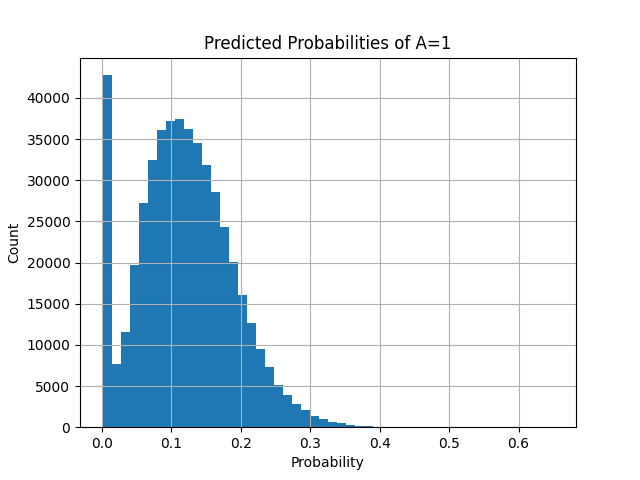

In [92]:
plt.hist(pred_probs, bins=50)
plt.title("Predicted Probabilities of A=1")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [93]:
from sklearn.metrics import classification_report, roc_auc_score

# Assume your true values are in `y_true` and predicted probs from `fit.predict()`
y_pred = (pred_probs > 0.2).astype(int)

print(classification_report(As, y_pred))
print("ROC AUC:", roc_auc_score(As, pred_probs))


              precision    recall  f1-score   support

         0.0       0.89      0.89      0.89    433090
         1.0       0.22      0.21      0.22     58418

    accuracy                           0.81    491508
   macro avg       0.55      0.55      0.55    491508
weighted avg       0.81      0.81      0.81    491508

ROC AUC: 0.6852423819688478


In [94]:
from sklearn.metrics import average_precision_score
average_precision = average_precision_score(As, pred_probs)
print("Average Precision (PR AUC):", average_precision)


Average Precision (PR AUC): 0.19300823995382663


In [95]:
NC = g.summary_dict['sim_data']['Natural course']

In [96]:
NC.groupby('admission_id')['t0'].max().max()

np.int64(85)

In [97]:
DS = g.summary_dict['sim_data']['Discharge safe']

KeyError: 'Discharge safe'

In [ ]:
# Compute LOS per admission
los_per_admission = NC.groupby('admission_id')['t0'].max() + 1  # +1 since t0 starts at 0

# Plot histogram
plt.figure(figsize=(8, 5))
los_per_admission.hist(bins=range(1, los_per_admission.max() + 2), edgecolor='black')
plt.xlabel("Length of Stay (number of time points)")
plt.ylabel("Number of Admissions")
plt.title("Distribution of Length of Stay")
plt.grid(True)
plt.tight_layout()
plt.savefig("los_NC.pdf")
plt.show()

In [ ]:
los_per_admission = DS.groupby('admission_id')['t0'].max() + 1

In [ ]:
# Compute LOS (number of time points) per admission
los_per_admission = DS.groupby('admission_id')['t0'].max() + 1  # +1 since t0 starts at 0

# Plot histogram
plt.figure(figsize=(8, 5))
los_per_admission.hist(bins=range(1, los_per_admission.max() + 2), edgecolor='black')
plt.xlabel("Length of Stay (number of time points)")
plt.ylabel("Number of Admissions")
plt.title("Distribution of Length of Stay")
plt.grid(True)
plt.tight_layout()
plt.savefig("los_mimic.pdf")
plt.show()

In [ ]:
DS = g.summary_dict['sim_data']['Discharge safe']
#DR = g.summary_dict['sim_data']['Discharge risky']
#DD = g.summary_dict['sim_data']['Discharge dangerous']

In [ ]:
DS

In [ ]:
# Compute LOS
los_ds = DS.groupby('admission_id')['t0'].max() + 1
#los_dr = DR.groupby('admission_id')['t0'].max() + 1
#los_dd = DD.groupby('admission_id')['t0'].max() + 1

# Create vertically stacked subplots
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=True)

# Plot for DS
axs[0].hist(los_ds, bins=range(1, 200), edgecolor='black', color='skyblue')
axs[0].set_title('LOS Distribution: DS')
axs[0].set_xlabel('Length of Stay (number of time points)')
axs[0].set_ylabel('Number of Admissions')
axs[0].grid(True)

# Plot for DR
axs[1].hist(los_dr, bins=range(1, 200), edgecolor='black', color='salmon')
axs[1].set_title('LOS Distribution: DR')
axs[1].set_xlabel('Length of Stay (number of time points)')
axs[1].set_ylabel('Number of Admissions')
axs[1].grid(True)

# Plot for DD
axs[2].hist(los_dd, bins=range(1, 200), edgecolor='black', color='salmon')
axs[2].set_title('LOS Distribution: DD')
axs[2].set_xlabel('Length of Stay (number of time points)')
axs[2].set_ylabel('Number of Admissions')
axs[2].grid(True)

# Final layout
plt.tight_layout()
plt.savefig("los_comp.pdf")
plt.show()


# Inspect percentage of in-icu death

In [ ]:
(
    mimicdata.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)['D']
             .mean()
)

In [ ]:
last_rows = (
    NC.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)
)
((last_rows['A'] == 0) & (last_rows['Py'] == 1)).mean()

In [ ]:
NC.A

In [ ]:
(
    NC.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)['D']
             .mean()
)

# Mean Y per LOS

In [ ]:
# Step 1: Get the last row for each admission (i.e., end of follow-up)
last_rows = mimicdata.sort_values("t0").groupby("admission_id").tail(1)

# Step 2: Calculate LOS for each admission
last_rows["los"] = mimicdata.groupby("admission_id")["t0"].nunique().values

# Step 3: Group by LOS and compute mean Y
mean_y_per_los = last_rows.groupby("los")["Y"].mean().reset_index()

# Step 4: Display
print(mean_y_per_los)


In [ ]:
mean_y_per_los.Y.mean()

In [ ]:
IPW = g.summary_dict['IP_weights']

In [ ]:
NC

# Distribution of GCS when A=1

In [ ]:
DI = g.summary_dict['sim_data']['Discharge extremely dangerous']

In [ ]:
DI

In [ ]:
# Filter data where A == 1
subset = DI[DI['A'] == 1]

# Plot distribution of X
plt.figure(figsize=(8, 5))
subset['glasgow_coma_scale_total__last__last_12h'].hist(bins=30, edgecolor='black')
plt.xlabel("L values (when A=1)")
plt.ylabel("Frequency")
plt.title("Distribution of X for A=1")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Filter data where A == 1
subset = NC[NC['A'] == 1]

# Plot distribution of X
plt.figure(figsize=(8, 5))
subset['glasgow_coma_scale_total__last__last_12h'].hist(bins=30, edgecolor='black')
plt.xlabel("L values (when A=1)")
plt.ylabel("Frequency")
plt.title("Distribution of X for A=1")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
NC

In [ ]:
# Filter rows where A == 1
subset = DI[DI['A'] == 1]

# Loop through each variable in L
for var in picked_for_L:
    print(f"\n--- Variable: {var} ---")
    
    if pd.api.types.is_numeric_dtype(subset[var]):
        # For continuous variable: show min, max, mean
        print("Type: Continuous")
        print("Min:", subset[var].min())
        print("Max:", subset[var].max())
        print("Mean:", round(subset[var].mean(), 2))
    else:
        # For categorical variable: show value counts
        print("Type: Categorical")
        print(subset[var].value_counts(dropna=False))
